# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import time
import pickle
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_recall_curve, recall_score, roc_curve, precision_score
from sklearn.metrics import  PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import re
from androguard.core.bytecodes.apk import APK
from androguard.core.bytecodes.dvm import DalvikVMFormat
from androguard.misc import AnalyzeAPK

import matplotlib.pyplot as plt

# Load Data

In [3]:
data = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv", encoding="utf-8", low_memory=False, na_values="?")
data.head()

,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S


In [4]:
data.shape

(15036, 216)

In [5]:
data.isnull().sum().sum()

5

In [6]:
feature_df = pd.read_csv("dataset-features-categories.csv", header=None, names=["X", "Category"])
feature_df.head()

,X,Category
0,transact,API call signature
1,onServiceConnected,API call signature
2,bindService,API call signature
3,attachInterface,API call signature
4,ServiceConnection,API call signature


In [7]:
feature_df["Category"].value_counts()

Category
Manifest Permission    113
API call signature      73
Intent                  23
Commands signature       6
B=Benign; S=Malware      1
Name: count, dtype: int64

In [8]:
feature_df.shape

(216, 2)

In [9]:
feature_df.isnull().sum().sum()

0

In [10]:
feature_df[feature_df["Category"] == "Manifest Permission"]

,X,Category
6,SEND_SMS,Manifest Permission
13,READ_PHONE_STATE,Manifest Permission
19,GET_ACCOUNTS,Manifest Permission
20,RECEIVE_SMS,Manifest Permission
22,READ_SMS,Manifest Permission
...,...,...
210,WRITE_EXTERNAL_STORAGE,Manifest Permission
211,ACCESS_FINE_LOCATION,Manifest Permission
212,SET_WALLPAPER_HINTS,Manifest Permission
213,SET_PREFERRED_APPLICATIONS,Manifest Permission


In [11]:
feature_df[feature_df["Category"] == "API call signature"]

,X,Category
0,transact,API call signature
1,onServiceConnected,API call signature
2,bindService,API call signature
3,attachInterface,API call signature
4,ServiceConnection,API call signature
...,...,...
167,ProcessBuilder,API call signature
171,Ljava.lang.Class.getResource,API call signature
172,defineClass,API call signature
180,findClass,API call signature


In [12]:
feature_df[feature_df["Category"] == "Intent"]

,X,Category
25,android.intent.action.BOOT_COMPLETED,Intent
53,android.intent.action.PACKAGE_REPLACED,Intent
55,android.intent.action.SEND_MULTIPLE,Intent
66,android.intent.action.TIME_SET,Intent
73,android.intent.action.PACKAGE_REMOVED,Intent
74,android.intent.action.TIMEZONE_CHANGED,Intent
81,android.intent.action.ACTION_POWER_DISCONNECTED,Intent
82,android.intent.action.PACKAGE_ADDED,Intent
97,android.intent.action.ACTION_SHUTDOWN,Intent
107,android.intent.action.PACKAGE_DATA_CLEARED,Intent


In [13]:
feature_df[feature_df["Category"] == "Commands signature"]

,X,Category
44,mount,Commands signature
79,chmod,Commands signature
96,remount,Commands signature
100,chown,Commands signature
141,/system/bin,Commands signature
149,/system/app,Commands signature


# Preprocess

In [14]:
data["class"] = data["class"].map({"B": 0, "S": 1})

In [15]:
data.head()

,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1


In [16]:
data = data.dropna()

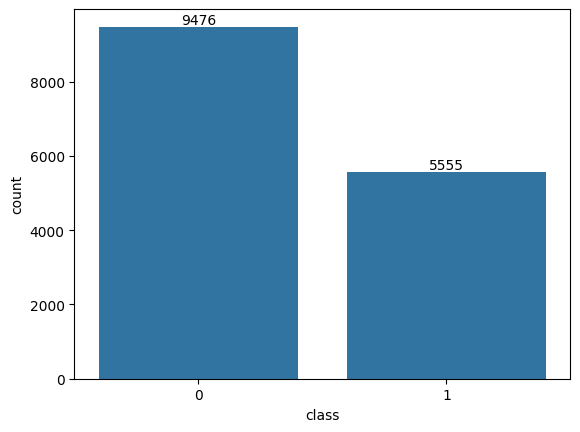

In [17]:
plt.figure()
ax = sns.countplot(data=data, x="class")
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [18]:
X = data.drop("class", axis=1)
y = data["class"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

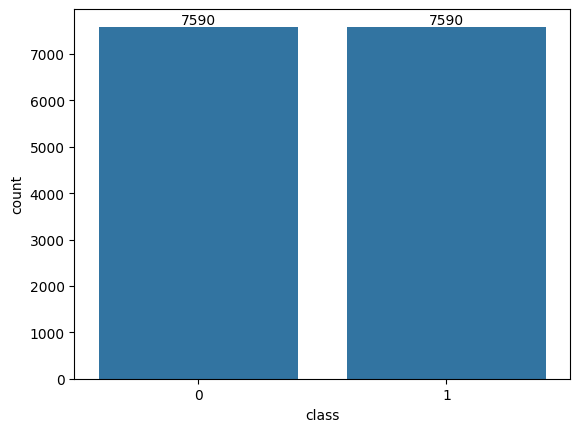

In [21]:
plt.figure()
ax = sns.countplot(x=y_train)
for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Model

# Logistic Regression

In [22]:
logreg = LogisticRegression()
start = time.time()
logreg.fit(X_train, y_train)
end = time.time()
logreg_time = end - start
print("Logistic Regression Train Time:", logreg_time)

Logistic Regression Train Time: 0.24399590492248535


In [23]:
logreg_pred_train = logreg.predict(X_train)
logreg_pred_test = logreg.predict(X_test)

logreg_train_score = accuracy_score(logreg_pred_train, y_train)
logreg_test_score = accuracy_score(logreg_pred_test, y_test)
print("Logistic Regression Train Score:", logreg_train_score)
print("Logistic Regression Test Score:", logreg_test_score)

Logistic Regression Train Score: 0.9814229249011858
Logistic Regression Test Score: 0.9760558696375125


In [24]:
logreg_precision_score = precision_score(y_test, logreg_pred_test)
logreg_f1_score = f1_score(y_test, logreg_pred_test)
logreg_recall_score = recall_score(y_test, logreg_pred_test)
logreg_accuracy_score = accuracy_score(y_test, logreg_pred_test)

print("Logistic Regression Precision Score:", logreg_precision_score)
print("Logistic Regression F1 Score:", logreg_f1_score)
print("Logistic Regression Recall Score:", logreg_recall_score)
print("Logistic Regression Accuracy Score:", logreg_accuracy_score)

Logistic Regression Precision Score: 0.9596844872918493
Logistic Regression F1 Score: 0.9681697612732095
Logistic Regression Recall Score: 0.9768064228367529
Logistic Regression Accuracy Score: 0.9760558696375125


In [25]:
print(classification_report(y_test, logreg_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1886
           1       0.96      0.98      0.97      1121

    accuracy                           0.98      3007
   macro avg       0.97      0.98      0.97      3007
weighted avg       0.98      0.98      0.98      3007



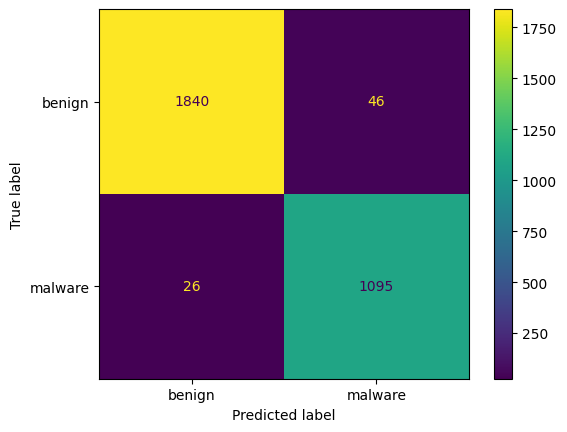

In [26]:
logreg_cm = confusion_matrix(y_test, logreg_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_cm, display_labels=["benign", "malware"])
disp.plot()
plt.show()

In [27]:
logreg_test_proba = logreg.predict_proba(X_test)[:, 1]

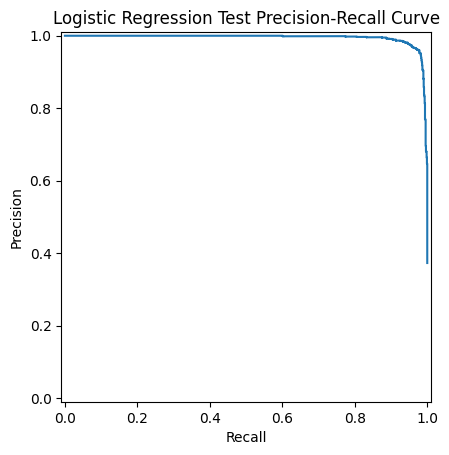

In [28]:
precision, recall, _ = precision_recall_curve(y_test, logreg_test_proba)
PrecisionRecallDisplay(precision, recall).plot()
plt.title("Logistic Regression Test Precision-Recall Curve")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


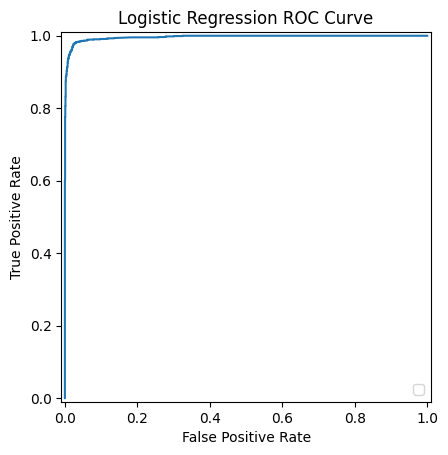

In [30]:
falsepr, truepr, _ = roc_curve(y_test, logreg_test_proba) 
RocCurveDisplay(fpr=falsepr, tpr=truepr).plot()
plt.title("Logistic Regression ROC Curve")
plt.show()

# Decision Tree

In [31]:
dt = DecisionTreeClassifier()
start = time.time()
dt.fit(X_train, y_train)
end = time.time()
dt_time = end - start
print("Decision Tree Train Time:", dt_time)

Decision Tree Train Time: 0.5966579914093018


In [32]:
dt_pred_train = dt.predict(X_train)
dt_pred_test = dt.predict(X_test)

dt_train_score = accuracy_score(dt_pred_train, y_train)
dt_test_score = accuracy_score(dt_pred_test, y_test)
print("Decision Tree Train Score:", dt_train_score)
print("Decision Tree Test Score:", dt_test_score)

Decision Tree Train Score: 0.9994071146245059
Decision Tree Test Score: 0.9704023944130362


In [33]:
dt_precision_score = precision_score(y_test, dt_pred_test)
dt_f1_score = f1_score(y_test, dt_pred_test)
dt_recall_score = recall_score(y_test, dt_pred_test)
dt_accuracy_score = accuracy_score(y_test, dt_pred_test)

print("Decision Tree Precision Score:", dt_precision_score)
print("Decision Tree F1 Score:", dt_f1_score)
print("Decision Tree Recall Score:", dt_recall_score)
print("Decision Tree Accuracy Score:", dt_accuracy_score)

Decision Tree Precision Score: 0.9615384615384616
Decision Tree F1 Score: 0.9602501116569897
Decision Tree Recall Score: 0.9589652096342551
Decision Tree Accuracy Score: 0.9704023944130362


In [34]:
print(classification_report(y_test, dt_pred_test))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1886
           1       0.96      0.96      0.96      1121

    accuracy                           0.97      3007
   macro avg       0.97      0.97      0.97      3007
weighted avg       0.97      0.97      0.97      3007



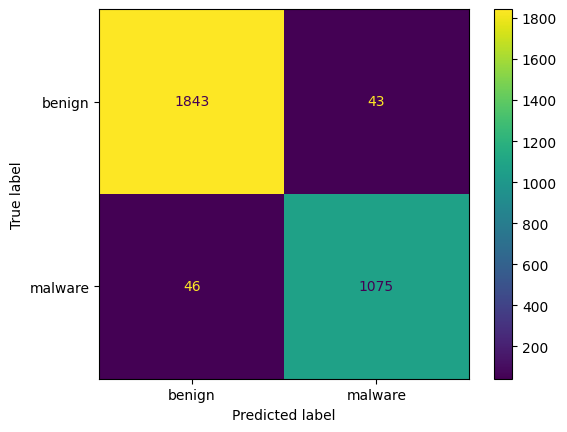

In [35]:
dt_cm = confusion_matrix(y_test, dt_pred_test)
ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=["benign", "malware"]).plot()
plt.show()

In [36]:
dt_test_proba = dt.predict_proba(X_test)[:, 1]

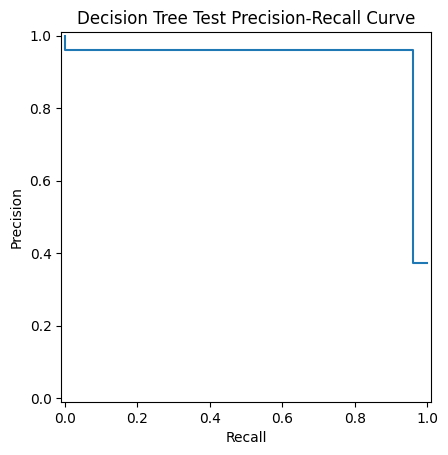

In [37]:
precision, recall, _ = precision_recall_curve(y_test, dt_test_proba)
PrecisionRecallDisplay(precision, recall).plot()
plt.title("Decision Tree Test Precision-Recall Curve")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


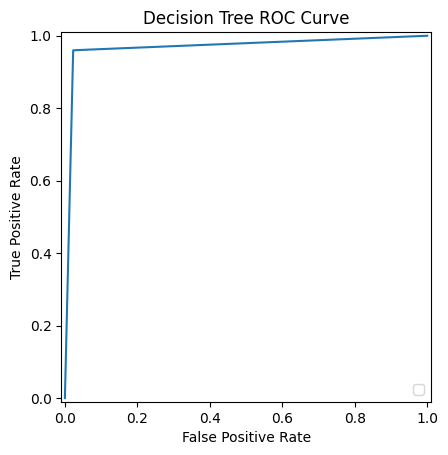

In [41]:
falsepr, truepr, _ = roc_curve(y_test, dt_test_proba) 
RocCurveDisplay(fpr=falsepr, tpr=truepr).plot()
plt.title("Decision Tree ROC Curve")
plt.show()

# Random Forestrf = RandomForestClassifier()

In [42]:
rf = RandomForestClassifier()
start = time.time()
rf.fit(X_train, y_train)
end = time.time()
rf_time = end - start
print("Random Forest Train Time:", rf_time)

Random Forest Train Time: 2.662844657897949


In [43]:
rf_pred_train = rf.predict(X_train)
rf_pred_test = rf.predict(X_test)

rf_train_score = accuracy_score(rf_pred_train, y_train)
rf_test_score = accuracy_score(rf_pred_test, y_test)
print("Random Forest Train Score:", rf_train_score)
print("Random Forest Test Score:", rf_test_score)

Random Forest Train Score: 0.9994071146245059
Random Forest Test Score: 0.9866977053541736


In [44]:
rf_precision_score = precision_score(y_test, rf_pred_test)
rf_f1_score = f1_score(y_test, rf_pred_test)
rf_recall_score = recall_score(y_test, rf_pred_test)
rf_accuracy_score = accuracy_score(y_test, rf_pred_test)

print("Random Forest Precision Score:", rf_precision_score)
print("Random Forest F1 Score:", rf_f1_score)
print("Random Forest Recall Score:", rf_recall_score)
print("Random Forest Accuracy Score:", rf_accuracy_score)

Random Forest Precision Score: 0.993607305936073
Random Forest F1 Score: 0.9819494584837545
Random Forest Recall Score: 0.9705619982158786
Random Forest Accuracy Score: 0.9866977053541736


In [45]:
print(classification_report(y_test, rf_pred_test))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1886
           1       0.99      0.97      0.98      1121

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.99      3007
weighted avg       0.99      0.99      0.99      3007



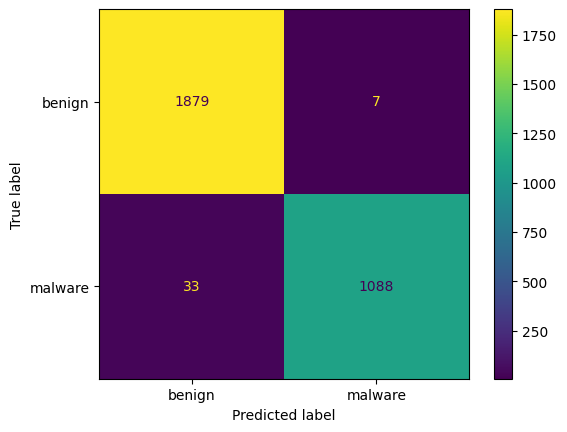

In [46]:
rf_cm = confusion_matrix(y_test, rf_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=["benign", "malware"])
disp.plot()
plt.show()

In [47]:
rf_test_proba = rf.predict_proba(X_test)[:, 1]

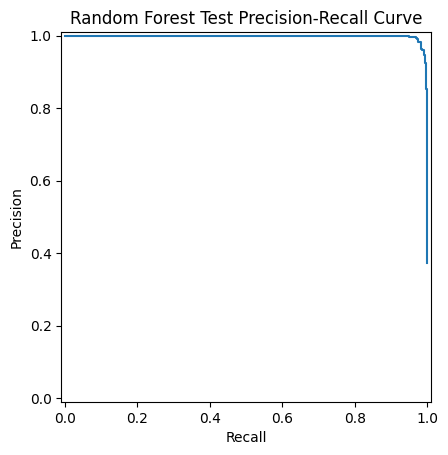

In [48]:
precision, recall, _ = precision_recall_curve(y_test, rf_test_proba)
PrecisionRecallDisplay(precision, recall).plot()
plt.title("Random Forest Test Precision-Recall Curve")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


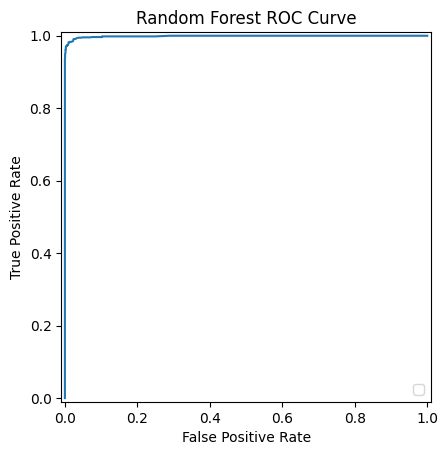

In [49]:
falsepr, truepr, _ = roc_curve(y_test, rf_test_proba) 
RocCurveDisplay(fpr=falsepr, tpr=truepr).plot()
plt.title("Random Forest ROC Curve")
plt.show()

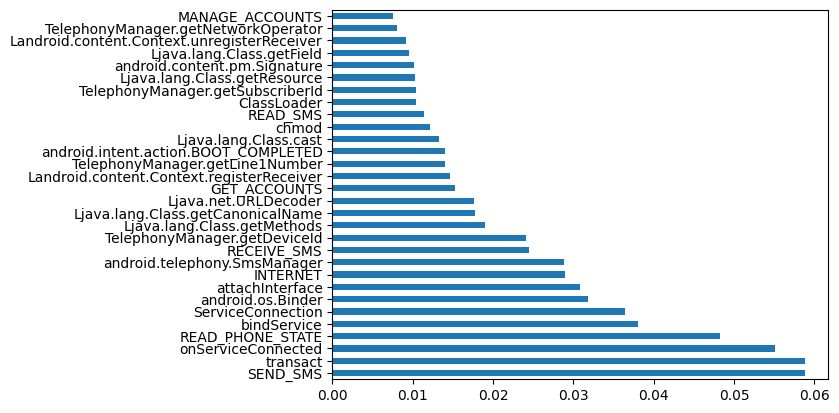

In [50]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(30).plot(kind='barh')
plt.show()

# XGB

In [51]:
xgb = XGBClassifier()
start = time.time()
xgb.fit(X_train, y_train)
end = time.time()
xgb_time = end - start
print("XGBClassifier Train Time:", xgb_time)

XGBClassifier Train Time: 0.9363193511962891


In [52]:
xgb_pred_train = xgb.predict(X_train)
xgb_pred_test = xgb.predict(X_test)

xgb_train_score = accuracy_score(xgb_pred_train, y_train)
xgb_test_score = accuracy_score(xgb_pred_test, y_test)
print("XGBClassifier Train Score:", xgb_train_score)
print("XGBClassifier Test Score:", xgb_test_score)

XGBClassifier Train Score: 0.9980237154150198
XGBClassifier Test Score: 0.985367475889591


In [53]:
xgb_precision_score = precision_score(y_test, xgb_pred_test)
xgb_f1_score = f1_score(y_test, xgb_pred_test)
xgb_recall_score = recall_score(y_test, xgb_pred_test)
xgb_accuracy_score = accuracy_score(y_test, xgb_pred_test)

print("XGBClassifier Precision Score:", xgb_precision_score)
print("XGBClassifier F1 Score:", xgb_f1_score)
print("XGBClassifier Recall Score:", xgb_recall_score)
print("XGBClassifier Accuracy Score:", xgb_accuracy_score)

XGBClassifier Precision Score: 0.9855725879170424
XGBClassifier F1 Score: 0.9802690582959641
XGBClassifier Recall Score: 0.9750223015165032
XGBClassifier Accuracy Score: 0.985367475889591


In [54]:
print(classification_report(y_test, xgb_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1886
           1       0.99      0.98      0.98      1121

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.98      3007
weighted avg       0.99      0.99      0.99      3007



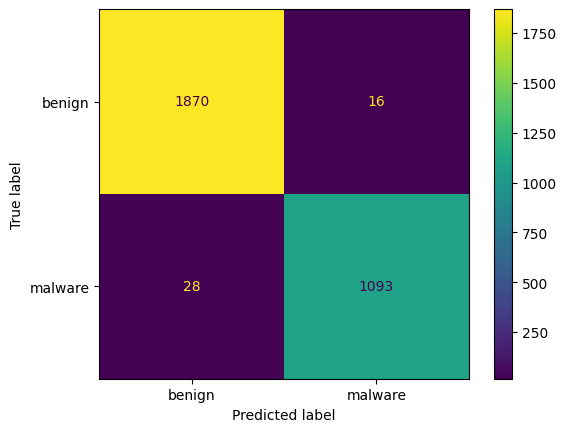

In [55]:
xgb_cm = confusion_matrix(y_test, xgb_pred_test)
ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=["benign", "malware"]).plot()
plt.show()
plt.show()

In [56]:
xgb_test_proba = xgb.predict_proba(X_test)[:, 1]

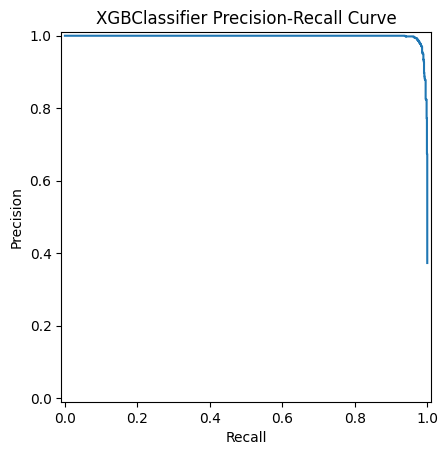

In [57]:
precision, recall, _ = precision_recall_curve(y_test, xgb_test_proba)
PrecisionRecallDisplay(precision, recall).plot()
plt.title("XGBClassifier Precision-Recall Curve")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


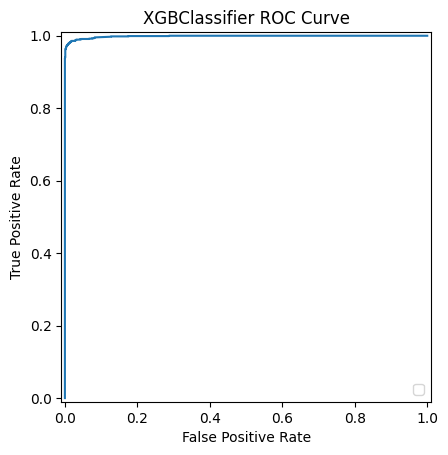

In [58]:
falsepr, truepr, _ = roc_curve(y_test, xgb_test_proba) 
RocCurveDisplay(fpr=falsepr, tpr=truepr).plot()
plt.title("XGBClassifier ROC Curve")
plt.show()

# Results

In [59]:
labels = ["LR", "DT", "RF", "XGB"]
scores = [logreg_test_score, dt_test_score, rf_test_score, xgb_test_score]

In [60]:
def plot_model_plot(labels, scores):
    plt.figure()
    ax = sns.barplot(x=labels, y=scores)
    ax.set_title("Trained Models Accuracy")
    for container in ax.containers:
        ax.bar_label(container)

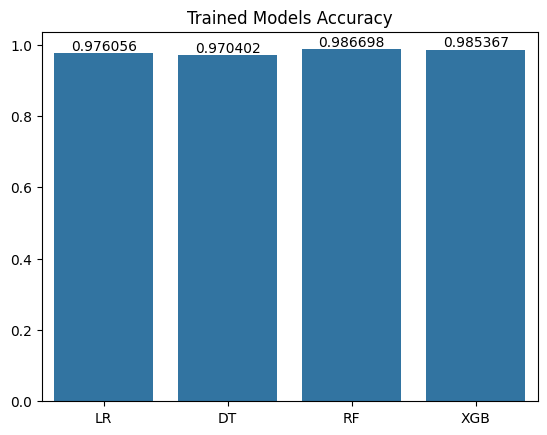

In [61]:
plot_model_plot(labels, scores)
plt.show()

# Test

In [62]:
permissions_list = feature_df[feature_df["Category"] == "Manifest Permission"].X.unique()
api_call_signatures = feature_df[feature_df["Category"] == "API call signature"].X.unique()
intents = feature_df[feature_df["Category"] == "Intent"].X.unique()
keywords = feature_df[feature_df["Category"] == "Commands signature"].X.unique()

In [63]:
columns = ["filename"]
for col in data.columns:
    columns.append(col)

In [64]:
test_df = pd.DataFrame(columns=columns)

In [65]:
apk_file_path = "com-cloudflare-onedotonedotonedotone-3837-66752135-ef8b2f5f382404189163d4d14c3128a8.apk"

In [66]:
test_df.loc[0, "filename"] = apk_file_path

In [67]:
test_df.head()

,filename,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,com-cloudflare-onedotonedotonedotone-3837-6675...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
a = APK(apk_file_path)
d = DalvikVMFormat(a.get_dex())

Requested API level 33 is larger than maximum we have, returning API level 28 instead.


In [69]:
permissions = a.get_permissions()
manifest = a.get_android_manifest_xml()
intent_filters = manifest.findall(".//intent-filter")

In [70]:
found_permissions = []
found_api_signatures = []
found_intents = []
found_keywords = []

In [71]:
for permission in permissions:
    permission = permission.split(".")[-1]
    if permission in permissions_list:
        found_permissions.append(permission)

In [72]:
for permission in permissions_list:
    if permission in found_permissions:
        test_df[permission] = 1
    else:
        test_df[permission] = 0

In [73]:
test_df.head()

,filename,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,com-cloudflare-onedotonedotonedotone-3837-6675...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,0,0,0,1,1,0,0,0,0,NaN


In [74]:
for method in d.get_methods():
    for api_call in api_call_signatures:
        # Ensure method descriptor is a string
        descriptor = method.get_descriptor()
        if isinstance(descriptor, bytes):
            descriptor = descriptor.decode('utf-8')
        
        if re.search(api_call, descriptor):
            found_api_signatures.append(api_call)


In [75]:
for api_call in api_call_signatures:
    if api_call in found_api_signatures:
        test_df[api_call] = 1
    else:
        test_df[api_call] = 0

In [76]:
test_df.head()

,filename,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,com-cloudflare-onedotonedotonedotone-3837-6675...,0,0,0,0,1,0,0,0,0,...,0,0,0,1,1,0,0,0,0,NaN


In [77]:
for intent_filter in intent_filters:
    action_elements = intent_filter.findall(".//action")
    for action_element in action_elements:
        action_value = action_element.get("{http://schemas.android.com/apk/res/android}name")
        for intent in intents:
            if re.search(intent, action_value):
                found_intents.append(intent)

In [78]:
for intent in intents:
    if intent in found_intents:
        test_df[intent] = 1
    else:
        test_df[intent] = 0

In [79]:
test_df.head()

,filename,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,com-cloudflare-onedotonedotonedotone-3837-6675...,0,0,0,0,1,0,0,0,0,...,0,0,0,1,1,0,0,0,0,NaN


In [80]:
for method in d.get_methods():
    for keyword in keywords:
        try:
            if re.search(keyword, method.get_code().get_instruction()):
                found_keywords.append(keyword)
        except:
            pass

In [81]:
for keyword in keywords:
    if keyword in found_keywords:
        test_df[keyword] = 1
    else:
        test_df[keyword] = 0

In [82]:
test_df.head()

,filename,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,com-cloudflare-onedotonedotonedotone-3837-6675...,0,0,0,0,1,0,0,0,0,...,0,0,0,1,1,0,0,0,0,NaN


In [83]:
test_df.isnull().sum().sum()

1

In [84]:
dropped = test_df.drop("filename", axis=1)
dropped = dropped.drop(columns=["class"])

In [86]:
result = rf.predict(dropped)
if result == 0:
    print("Benign")
elif result == 1:
    print("Malware")

Benign
